# Hybrid Model: LSTM + XGBoost Residual Corrector
---
## Notebook 2 of 2 — Heatwave Temperature Forecasting (Uttar Pradesh, India)

This notebook builds the second stage of a **Residual Hybrid Model**:

- **Notebook 1 (complete):** Trained an LSTM baseline that forecasts maximum temperature (T2M_MAX) for the next 10 days using 30 days of meteorological history.
- **Notebook 2 (this notebook):** Trains an XGBoost model to learn and correct the LSTM's errors (residuals).

### Final Formula:
    y_final = y_lstm + y_xgb_residual

### Why a Residual Hybrid?
The LSTM captures temporal patterns well but drifts on longer horizons (days 7–10). XGBoost cannot process sequences directly, but it excels at learning structured, tabular corrections. Together they complement each other — LSTM handles the sequence modeling, XGBoost handles the error correction.

### Files Loaded From Notebook 1
| File | Shape | Description |
|---|---|---|
| y_lstm_val.npy | (360375, 10) | LSTM predictions on validation set |
| y_lstm_test.npy | (314625, 10) | LSTM predictions on test set |
| y_val_seq.npy | (360375, 10) | Ground truth — validation set |
| y_test_seq.npy | (314625, 10) | Ground truth — test set |
| X_val_last.npy | (360375, 22) | Last timestep of val sequences (current conditions) |
| X_test_last.npy | (314625, 22) | Last timestep of test sequences (current conditions) |

In [1]:
import numpy as np

BASE = '/kaggle/input/notebooks/tarunraii/lstm-heatwave-project-ipynb/'

# Load LSTM predictions
y_lstm_val  = np.load(BASE + 'y_lstm_val.npy')   # (360375, 10)
y_lstm_test = np.load(BASE + 'y_lstm_test.npy')  # (314625, 10)

# Load ground truth
y_val_seq  = np.load(BASE + 'y_val_seq.npy')     # (360375, 10)
y_test_seq = np.load(BASE + 'y_test_seq.npy')    # (314625, 10)

# Load last timestep features
X_val_last  = np.load(BASE + 'X_val_last.npy')   # (360375, 22)
X_test_last = np.load(BASE + 'X_test_last.npy')  # (314625, 22)

# Sanity check — confirm all shapes
print("y_lstm_val  :", y_lstm_val.shape)
print("y_lstm_test :", y_lstm_test.shape)
print("y_val_seq   :", y_val_seq.shape)
print("y_test_seq  :", y_test_seq.shape)
print("X_val_last  :", X_val_last.shape)
print("X_test_last :", X_test_last.shape)

y_lstm_val  : (360375, 10)
y_lstm_test : (314625, 10)
y_val_seq   : (360375, 10)
y_test_seq  : (314625, 10)
X_val_last  : (360375, 22)
X_test_last : (314625, 22)


## Step 1 — Compute Residuals and Train XGBoost Residual Corrector

### What are residuals?
Residuals are the LSTM's prediction errors on the validation set:
residual = y_true - y_lstm_prediction
A positive residual means LSTM underpredicted. A negative residual means it overpredicted.

### Why train XGBoost on validation residuals (not training residuals)?
The LSTM has partially memorized training sequences, so its training errors are artificially small and unrepresentative of real-world performance. For example, if the LSTM saw a sequence during training, it may predict it near-perfectly — not because it understood the pattern, but because it memorized it. Validation residuals reflect genuine LSTM weaknesses on truly unseen data — XGBoost trained here will generalize properly to the test set.

### Why use only the last day of each sequence as input to XGBoost?
Each input sequence has shape (30 days, 22 features). XGBoost requires a flat 1D feature vector per sample — it cannot process sequences directly. We have two options:
- **Flatten all 30 days** → 30 × 22 = 660 features per sample. This is too large, introduces redundant historical information, and massively increases overfitting risk.
- **Use only the last day (day 30)** → 22 features per sample. Day 30 represents the most recent state of the atmosphere — temperature, humidity, soil dryness, radiation, wind — which is the most predictive snapshot of current conditions and therefore the most informative signal for correcting the LSTM's upcoming forecast.

The last timestep is essentially "what the world looks like right now" — the strongest single signal for diagnosing where the LSTM is likely to go wrong in the next 10 days.

### Design Decisions
- **One XGBoost model per horizon day (10 total):** Each day's error pattern is different. A single model treating all 10 days identically fails to capture this structure.
- **Input features:** Last timestep of the sequence (22 features) + LSTM's own prediction for that day (1 feature) = 23 features total. The LSTM's own forecast is the most informative signal about where it might be wrong — if LSTM predicts an unusually high temperature, XGBoost can learn whether that specific prediction tends to be an over or underestimate.
- **Heavy regularization:** `max_depth=3`, `min_child_weight=50`, `reg_alpha=1.0`, `reg_lambda=5.0` — prevents XGBoost from overfitting to validation residuals and ensures corrections generalize cleanly to the test set.

In [2]:
# Recompute residuals
residuals_val = y_val_seq - y_lstm_val  # (360375, 10)

print(f"Residuals recomputed — Mean: {residuals_val.mean():.4f}, Std: {residuals_val.std():.4f}")

Residuals recomputed — Mean: -0.3008, Std: 2.1978


In [3]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

residuals_val = y_val_seq - y_lstm_val

xgb_models_v4 = []

print("Training regularized XGBoost models...\n")
print(f"{'Day':<6} {'LSTM Val MAE':>13} {'Hybrid Val MAE':>15} {'Val Gain':>10}")
print("-" * 48)

for day in range(10):
    X_val_simple = np.hstack([
        X_val_last,
        y_lstm_val[:, day:day+1]   # just LSTM prediction for this day
    ])  # shape: (360375, 23)

    xgb = XGBRegressor(
        n_estimators=100,      # fewer trees
        max_depth=3,           # shallow — only simple patterns
        learning_rate=0.05,
        subsample=0.5,         # more aggressive subsampling
        colsample_bytree=0.5,
        min_child_weight=50,   # require many samples per leaf
        reg_alpha=1.0,         # L1 regularization
        reg_lambda=5.0,        # L2 regularization
        random_state=42,
        tree_method='hist',
        device='cuda',
        n_jobs=-1
    )
    xgb.fit(X_val_simple, residuals_val[:, day])
    xgb_models_v4.append(xgb)

    y_xgb_pred_val = xgb.predict(X_val_simple)
    lstm_val_mae   = mean_absolute_error(y_val_seq[:, day], y_lstm_val[:, day])
    hybrid_val_mae = mean_absolute_error(y_val_seq[:, day], y_lstm_val[:, day] + y_xgb_pred_val)
    print(f"{day+1:<6} {lstm_val_mae:>13.4f} {hybrid_val_mae:>15.4f} {lstm_val_mae - hybrid_val_mae:>+10.4f}")

Training regularized XGBoost models...

Day     LSTM Val MAE  Hybrid Val MAE   Val Gain
------------------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:31:08] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


1             1.3571          1.2954    +0.0617
2             1.4883          1.4351    +0.0532
3             1.5643          1.5079    +0.0564
4             1.6141          1.5507    +0.0634
5             1.6571          1.5797    +0.0774
6             1.6863          1.5982    +0.0881
7             1.7164          1.6168    +0.0996
8             1.7411          1.6330    +0.1081
9             1.7568          1.6487    +0.1081
10            1.7831          1.6604    +0.1227


## Step 2 — Generate Hybrid Predictions on Test Set

For each horizon day, XGBoost predicts the correction to apply to the LSTM's forecast.
The final hybrid prediction is simply: y_hybrid = y_lstm + y_xgb_correction

XGBoost only sees `X_test_last` (current conditions) and `y_lstm_test` (LSTM's forecast) — no future information is used. There is no data leakage.

In [4]:
# Generate test predictions
y_xgb_residual_test_v4 = np.zeros((X_test_last.shape[0], 10))
for day in range(10):
    X_test_simple = np.hstack([
        X_test_last,
        y_lstm_test[:, day:day+1]
    ])
    y_xgb_residual_test_v4[:, day] = xgb_models_v4[day].predict(X_test_simple)

y_hybrid_test = y_lstm_test + y_xgb_residual_test_v4
print("\nHybrid predictions generated.")


Hybrid predictions generated.


## Step 3 — Evaluate: Standalone LSTM vs Hybrid Model

We compare MAE (Mean Absolute Error) per forecast horizon day across the full test set (314,625 samples).

### What we expect
- Hybrid MAE should be lower than LSTM MAE on all or most horizon days
- Improvement should increase with horizon — LSTM drifts more on days 7–10, giving XGBoost more signal to correct
- No horizon should be significantly worse in the hybrid (that would indicate XGBoost is adding noise)

Day      LSTM MAE   Hybrid MAE   Improvement
-------------------------------------------
1          1.4135       1.3868      +0.0267  ✅
2          1.5417       1.5314      +0.0104  ✅
3          1.6240       1.6178      +0.0062  ✅
4          1.6860       1.6739      +0.0121  ✅
5          1.7357       1.7158      +0.0200  ✅
6          1.7714       1.7456      +0.0258  ✅
7          1.8106       1.7710      +0.0395  ✅
8          1.8403       1.7949      +0.0454  ✅
9          1.8576       1.8193      +0.0383  ✅
10         1.8893       1.8362      +0.0531  ✅

Overall LSTM MAE   : 1.7170°C
Overall Hybrid MAE : 1.6893°C
Overall Improvement: +0.0277°C


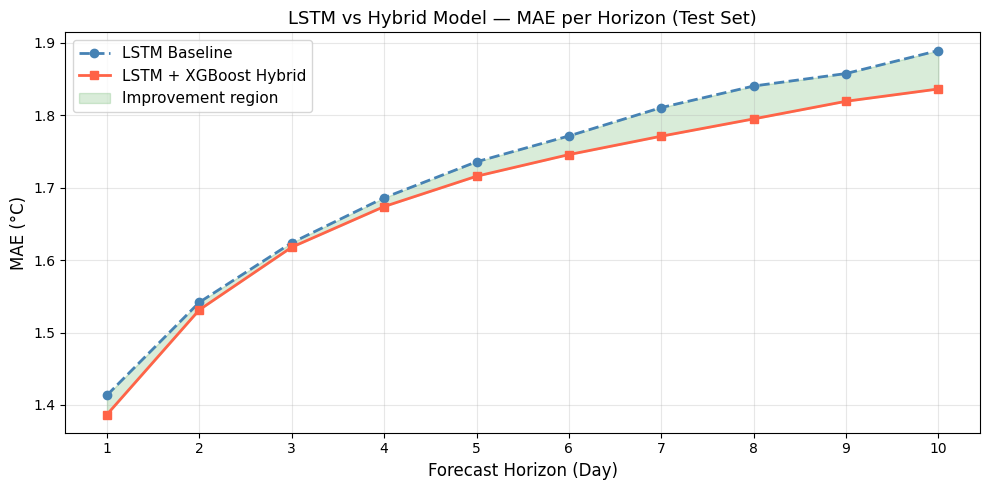

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

days = list(range(1, 11))

lstm_mae_per_day   = [mean_absolute_error(y_test_seq[:, d], y_lstm_test[:, d])
                      for d in range(10)]
hybrid_mae_per_day = [mean_absolute_error(y_test_seq[:, d], y_hybrid_test[:, d])
                      for d in range(10)]

print(f"{'Day':<6} {'LSTM MAE':>10} {'Hybrid MAE':>12} {'Improvement':>13}")
print("-" * 43)
for d, (l, h) in enumerate(zip(lstm_mae_per_day, hybrid_mae_per_day), 1):
    delta = l - h
    flag  = "✅" if delta > 0 else "❌"
    print(f"{d:<6} {l:>10.4f} {h:>12.4f} {delta:>+12.4f}  {flag}")

print(f"\nOverall LSTM MAE   : {sum(lstm_mae_per_day)/10:.4f}°C")
print(f"Overall Hybrid MAE : {sum(hybrid_mae_per_day)/10:.4f}°C")
print(f"Overall Improvement: {(sum(lstm_mae_per_day) - sum(hybrid_mae_per_day))/10:+.4f}°C")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(days, lstm_mae_per_day,   'o--', label='LSTM Baseline',         color='steelblue', linewidth=2)
ax.plot(days, hybrid_mae_per_day, 's-',  label='LSTM + XGBoost Hybrid', color='tomato',    linewidth=2)
ax.fill_between(days, lstm_mae_per_day, hybrid_mae_per_day,
                alpha=0.15, color='green', label='Improvement region')
ax.set_xlabel('Forecast Horizon (Day)', fontsize=12)
ax.set_ylabel('MAE (°C)', fontsize=12)
ax.set_title('LSTM vs Hybrid Model — MAE per Horizon (Test Set)', fontsize=13)
ax.set_xticks(days)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/mae_comparison.png', dpi=150)
plt.show()

## Step 4 — Save Final Models and Results

Saving all 10 XGBoost models, hybrid predictions, and MAE results for future use.

| File | Description |
|---|---|
| xgb_day1.pkl … xgb_day10.pkl | Trained XGBoost corrector for each horizon day |
| y_hybrid_test.npy | Final hybrid predictions on test set — shape (314625, 10) |
| y_xgb_residual_test.npy | Raw XGBoost corrections on test set — shape (314625, 10) |
| mae_results.pkl | Dictionary of MAE per day and overall MAE for both models |
| mae_comparison.png | Plot comparing LSTM vs Hybrid MAE across all horizon days |

In [6]:
import joblib
import numpy as np

# Save all 10 XGBoost models
for day in range(10):
    joblib.dump(xgb_models_v4[day], f'/kaggle/working/xgb_day{day+1}.pkl')

# Save final hybrid predictions
np.save('/kaggle/working/y_hybrid_test.npy', y_hybrid_test)
np.save('/kaggle/working/y_xgb_residual_test.npy', y_xgb_residual_test_v4)

# Save MAE results for reporting
mae_results = {
    'lstm_mae_per_day'  : lstm_mae_per_day,
    'hybrid_mae_per_day': hybrid_mae_per_day,
    'overall_lstm_mae'  : sum(lstm_mae_per_day) / 10,
    'overall_hybrid_mae': sum(hybrid_mae_per_day) / 10,
    'overall_improvement': (sum(lstm_mae_per_day) - sum(hybrid_mae_per_day)) / 10
}
joblib.dump(mae_results, '/kaggle/working/mae_results.pkl')

# Confirm all files saved
import os
files = [f for f in os.listdir('/kaggle/working/') if f.endswith(('.pkl', '.npy', '.png', '.keras'))]
for f in sorted(files):
    size = os.path.getsize(f'/kaggle/working/{f}') / 1024
    print(f"  {f:<40} {size:>8.1f} KB")

  mae_comparison.png                           80.5 KB
  mae_results.pkl                               0.3 KB
  xgb_day1.pkl                                118.0 KB
  xgb_day10.pkl                               118.1 KB
  xgb_day2.pkl                                117.8 KB
  xgb_day3.pkl                                118.1 KB
  xgb_day4.pkl                                118.0 KB
  xgb_day5.pkl                                118.0 KB
  xgb_day6.pkl                                118.1 KB
  xgb_day7.pkl                                118.1 KB
  xgb_day8.pkl                                118.1 KB
  xgb_day9.pkl                                118.1 KB
  y_hybrid_test.npy                         24580.2 KB
  y_xgb_residual_test.npy                   24580.2 KB
